# S8 — перенос калибровки между независимыми записями

## tl;dr

Сохранённые residual и tracker residual при истинном CV-состоянии совпадают до машинной точности: ошибки знака/единиц/базиса не обнаружено. После отдельного разрешённого **calibration-only** прогона 20 160 покадровых residuals показали резкое различие записей: mean separation `11.30–19.46°` для recorded против `0.003–0.022°` для broadband. Внутренний scatter проблемного Phantom-сеанса составляет `92.7–96.2%` pooled recorded scatter; верхние 5% ошибок сдвигают pooled mean на `4.25–4.42°`. Повторный replay 16 сохранённых evaluation-потоков подтвердил 32 парные ветви и неизменность опубликованного RMSE; на takeoff/hover при +10 dB post-hoc `bias=0` при той же R уменьшает условную position RMSE с 12.57–14.48 м до 0.73–0.74 м. Журнал 208 гипотезных диагностик показывает, что конкретный broadband-отказ произошёл при бюджете confirmation-refit, после трёх успешных refit. **Это диагностический анализ, не выбор новой рабочей калибровки.** Два исходных calibration-сеанса не дают статистической квалификации переноса.


## Контекст и метод

Изначальный saved-data аудит читал только `results/s8_tracking_feasibility_*`; затем с прямого разрешения пользователя были повторно обработаны только два calibration-сеанса (`S8_CALIBRATION_TRANSFER_PROTOCOL.md`). Evaluation audio и старые Monte Carlo не повторялись. Два исходных calibration-сеанса и два evaluation-сеанса не позволяют надёжно квалифицировать перенос; зависимые кадры не являются независимыми испытаниями. Bias/R привязаны к `station_id × estimator_variant × source_model`, в prediction-anchored ортонормированном касательном базисе и радианах дуги. Tracker вычисляет `Log_prediction(measurement) - bias`; covariance в рад². Post-hoc replay меняет только bias; R, события, `Qc`, пороги, бюджет и времена не меняются.


In [1]:
from pathlib import Path
import csv, json, sys
from collections import Counter, defaultdict
import numpy as np
import matplotlib.pyplot as plt
ROOT = Path.cwd()
if ROOT.name == 'notebooks': ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))
RESULTS = ROOT / 'results'
def load(name):
    with (RESULTS / name).open(newline='', encoding='utf-8') as handle:
        return list(csv.DictReader(handle))
cal = load('s8_tracking_feasibility_calibration.csv')
residuals = load('s8_calibration_transfer_evaluation_residuals.csv')
pools = load('s8_calibration_transfer_pool_comparison.csv')
replay = load('s8_calibration_transfer_replay.csv')
fits = load('s8_calibration_transfer_hypothesis_diagnostics.csv')
contract = json.loads((RESULTS / 's8_calibration_transfer_contract_audit.json').read_text(encoding='utf-8'))
print('pooled calibration / evaluation groups / replay arms / diagnostics:', len(cal), len(residuals), len(replay), len(fits))
print('contract maximum disagreement (rad):', contract['maximum_tracker_residual_at_truth_disagreement_rad'])


pooled calibration / evaluation groups / replay arms / diagnostics: 12 48 32 208
contract maximum disagreement (rad): 2.220446049250313e-16


## Проверка состава calibration-данных

Изначальный CSV хранил по одному pooled bias/R на комбинацию source model, станции и метода; `calibration_session_ids_json` — лишь список сеансов, не покадровые residual. Из общей пары моментов нельзя восстановить ни среднее каждого сеанса, ни ковариацию/выбросы внутри него. Историческая 2-секундная pooled таблица не устраняет эту неидентифицируемость; сравнение ниже показывает только чувствительность pooled итогов к изменению протокола 2→4.5 с, не изолированное влияние времени. **Этот исходный пробел закрыт отдельным разрешённым calibration-only прогоном ниже**; original pooled CSV при этом не перезаписан.


In [2]:
from validation.s8_calibration_transfer_analysis import assert_calibration_session_grain_available
try:
    assert_calibration_session_grain_available(cal)
except ValueError as exc:
    print('from original pooled CSV alone, leave-one-calibration-session-out is unavailable —', exc)
for source in ('recorded_source_approximation', 'random_broadband'):
    subset = [row for row in pools if row['source_model_comparison'] == source]
    print(source, 'pooled bias norm range deg:', round(min(float(row['current_pooled_bias_norm_deg']) for row in subset), 3), 'to', round(max(float(row['current_pooled_bias_norm_deg']) for row in subset), 3), 'max 2→4.5s change deg:', round(max(float(row['pooled_bias_duration_change_deg']) for row in subset), 3))


from original pooled CSV alone, leave-one-calibration-session-out is unavailable — session-grain calibration residuals were not persisted; leave-one-session-out and calibration outlier decomposition are not identifiable
recorded_source_approximation pooled bias norm range deg: 5.394 to 9.7 max 2→4.5s change deg: 9.289
random_broadband pooled bias norm range deg: 0.011 to 0.03 max 2→4.5s change deg: 0.037


## Дополнение: разрешённый calibration-only прогон

После исходного saved-data аудита были разрешены **только два исходных calibration-сеанса**. Протокол до расчёта записан в `S8_CALIBRATION_TRANSFER_PROTOCOL.md`: те же 4.5 с, два SNR, recorded/broadband pairing, seed и фронтенды. Evaluation-аудио, трекер и Monte Carlo не запускались. Ниже сохранённые offline residuals с исходным session ID; их можно повторно анализировать командой `python -m validation.s8_calibration_session_recovery --reanalyze-saved` без звука. Опубликованные pooled bias/R не меняются.


In [3]:
cal_frames=load('s8_calibration_transfer_calibration_residuals.csv')
cal_groups=load('s8_calibration_transfer_calibration_session_snr_summary.csv')
cal_attribution=load('s8_calibration_transfer_calibration_pool_attribution.csv')
cal_cross=load('s8_calibration_transfer_calibration_leave_one_session_out.csv')
cal_audit=json.loads((RESULTS/'s8_calibration_transfer_calibration_recovery_audit.json').read_text(encoding='utf-8'))
print('original calibration sessions:',cal_audit['original_session_count'],'dependent frames:',len(cal_frames))
print('session/SNR groups:',len(cal_groups),'pooled attribution groups:',len(cal_attribution),'directed cross-session checks:',len(cal_cross))
print('max reproduced bias/covariance difference:',cal_audit['maximum_pooled_bias_difference_rad'],cal_audit['maximum_pooled_covariance_difference_rad2'])
assert len(cal_frames)==20160 and len(cal_groups)==48 and len(cal_attribution)==12 and len(cal_cross)==48


original calibration sessions: 2 dependent frames: 20160
session/SNR groups: 48 pooled attribution groups: 12 directed cross-session checks: 48
max reproduced bias/covariance difference: 0.0 0.0


### Различие исходных сеансов и вклад в pooled R

Ковариация разложена точно: `(n−1)R_pooled = Σ_s(n_s−1)R_s + Σ_s n_s(μ_s−μ)(μ_s−μ)^T`. Второе слагаемое — межсеансовый scatter; его доля ниже описывает **эти две записи**, а не популяцию. Столбцы и точки по станциям/методам статистически зависимы. Панели recorded и broadband на первом графике имеют разные шкалы по вертикали.


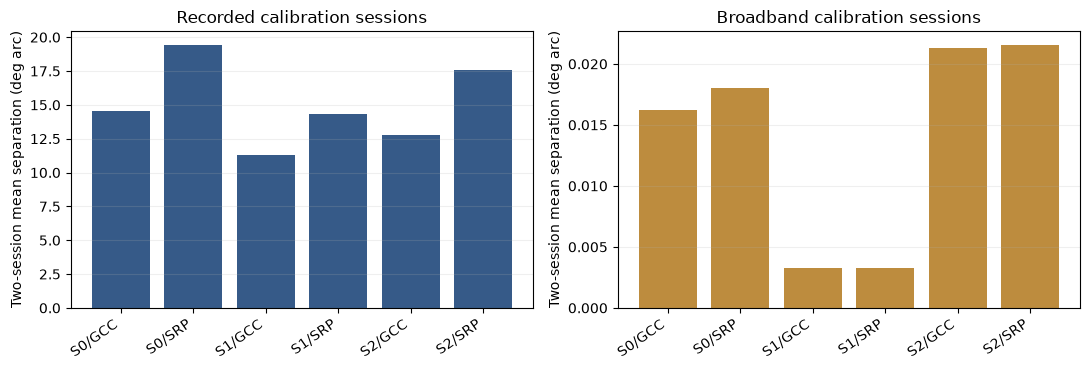

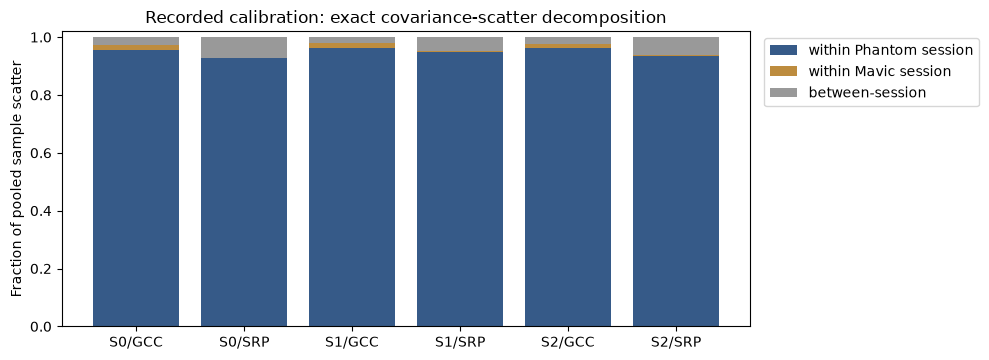

recorded_source_approximation mean separation deg range= 11.299 19.46 between-session scatter share range= 0.019 0.07 top-5% mean shift deg max= 4.42
random_broadband mean separation deg range= 0.003 0.022 between-session scatter share range= 0.0 0.001 top-5% mean shift deg max= 0.007


In [4]:
cal_labels=['S0/GCC','S0/SRP','S1/GCC','S1/SRP','S2/GCC','S2/SRP']
def ordered_source(source):
    items=[r for r in cal_attribution if r['source_model_comparison']==source]
    return sorted(items,key=lambda r:(r['station_id'],r['estimator_variant']))
fig,axes=plt.subplots(1,2,figsize=(11,3.8))
for ax,source,title,color in [(axes[0],'recorded_source_approximation','Recorded calibration sessions','#365a88'),(axes[1],'random_broadband','Broadband calibration sessions','#bd8c3e')]:
    items=ordered_source(source)
    ax.bar(np.arange(6),[float(r['session_mean_separation_deg']) for r in items],color=color)
    ax.set_xticks(np.arange(6),cal_labels,rotation=35,ha='right')
    ax.set_ylabel('Two-session mean separation (deg arc)')
    ax.set_title(title);ax.grid(axis='y',alpha=.2)
plt.tight_layout();plt.show()
items=ordered_source('recorded_source_approximation')
shares=[json.loads(r['session_within_scatter_trace_fraction_json']) for r in items]
phantom=[next(value for key,value in share.items() if key.startswith('alcappuccino')) for share in shares]
mavic=[next(value for key,value in share.items() if key.startswith('sadiquecat')) for share in shares]
between=[float(r['between_session_scatter_trace_fraction']) for r in items]
fig,ax=plt.subplots(figsize=(10,3.7));x=np.arange(6)
ax.bar(x,phantom,color='#365a88',label='within Phantom session')
ax.bar(x,mavic,bottom=phantom,color='#bd8c3e',label='within Mavic session')
ax.bar(x,between,bottom=np.asarray(phantom)+mavic,color='#999999',label='between-session')
ax.set_xticks(x,cal_labels);ax.set_ylim(0,1.02);ax.set_ylabel('Fraction of pooled sample scatter')
ax.set_title('Recorded calibration: exact covariance-scatter decomposition')
ax.legend(loc='upper left',bbox_to_anchor=(1.01,1));plt.tight_layout();plt.show()
for source in ('recorded_source_approximation','random_broadband'):
    items=ordered_source(source)
    print(source,'mean separation deg range=',round(min(float(r['session_mean_separation_deg']) for r in items),3),round(max(float(r['session_mean_separation_deg']) for r in items),3),'between-session scatter share range=',round(min(float(r['between_session_scatter_trace_fraction']) for r in items),3),round(max(float(r['between_session_scatter_trace_fraction']) for r in items),3),'top-5% mean shift deg max=',round(max(float(r['top_5pct_mean_shift_deg']) for r in items),3))


### Направленная проверка одного calibration-сеанса на другом

Каждый train использует оба предобъявленных SNR одного исходного сеанса, каждый test — один SNR другого. Величина `NIS=(r−μ_train)^T R_train⁻¹(r−μ_train)` вычислена с **train-only** bias/R. Chi-square(2) — лишь Gaussian benchmark для зависимых, явно негауссовых кадров; проценты не являются доверительными интервалами и два сеанса не квалифицируют перенос статистически.


In [5]:
for session in sorted({r['paired_session_id'] for r in cal_groups if r['source_model_comparison']=='recorded_source_approximation'}):
    for snr in ('-6.0','10.0'):
        group=[r for r in cal_groups if r['source_model_comparison']=='recorded_source_approximation' and r['paired_session_id']==session and r['snr_db']==snr]
        print(session[:22],snr,'median/P95 group-mean deg=',round(np.mean([float(r['median_error_deg']) for r in group]),2),round(np.mean([float(r['p95_error_deg']) for r in group]),2),'>30 fraction group-mean=',round(np.mean([float(r['fraction_gt_30deg']) for r in group]),3))
for source in ('recorded_source_approximation','random_broadband'):
    items=[r for r in cal_cross if r['source_model_comparison']==source]
    print(source,'directed groups=',len(items),'cross-session mean mismatch deg range=',tuple(round(v,3) for v in (min(float(r['test_minus_train_bias_norm_deg']) for r in items),max(float(r['test_minus_train_bias_norm_deg']) for r in items))),'chi2(2) P95 exceedance range=',tuple(round(v,3) for v in (min(float(r['centered_nis_fraction_gt_chi2_2_p95']) for r in items),max(float(r['centered_nis_fraction_gt_chi2_2_p95']) for r in items))))
print('Directed LOSO recorded-session diagnostics (descriptive mean across six dependent station/method groups):')
for train_session in sorted({r['train_session_id'] for r in cal_cross if r['source_model_comparison']=='recorded_source_approximation'}):
    for test_snr in ('-6.0','10.0'):
        items=[r for r in cal_cross if r['source_model_comparison']=='recorded_source_approximation' and r['train_session_id']==train_session and r['test_snr_db']==test_snr]
        print('train=',train_session,'test SNR=',test_snr,'mean bias mismatch deg=',round(np.mean([float(r['test_minus_train_bias_norm_deg']) for r in items]),2),'mean NIS P95=',round(np.mean([float(r['centered_nis_p95']) for r in items]),1),'mean chi2 exceedance=',round(np.mean([float(r['centered_nis_fraction_gt_chi2_2_p95']) for r in items]),3))
print('Maximum within/between scatter reconstruction error:',max(float(r['scatter_reconstruction_max_abs_rad2']) for r in cal_attribution))


alcappuccino-phantom-2 -6.0 median/P95 group-mean deg= 43.86 133.4 >30 fraction group-mean= 0.596
alcappuccino-phantom-2 10.0 median/P95 group-mean deg= 9.9 91.03 >30 fraction group-mean= 0.245
sadiquecat-mavic-mini- -6.0 median/P95 group-mean deg= 2.24 14.7 >30 fraction group-mean= 0.017
sadiquecat-mavic-mini- 10.0 median/P95 group-mean deg= 0.19 0.4 >30 fraction group-mean= 0.0
recorded_source_approximation directed groups= 24 cross-session mean mismatch deg range= (3.869, 30.792) chi2(2) P95 exceedance range= (0.0, 0.833)
random_broadband directed groups= 24 cross-session mean mismatch deg range= (0.003, 0.046) chi2(2) P95 exceedance range= (0.0, 0.248)
Directed LOSO recorded-session diagnostics (descriptive mean across six dependent station/method groups):
train= alcappuccino-phantom-2-gopro-takeoff-landing test SNR= -6.0 mean bias mismatch deg= 14.99 mean NIS P95= 0.4 mean chi2 exceedance= 0.0
train= alcappuccino-phantom-2-gopro-takeoff-landing test SNR= 10.0 mean bias mismatch de

## Held-out residual: сеансы, станции, методы и SNR

Это разложение **evaluation**, не утраченного calibration. Серые столбцы показывают средний residual в одном evaluation-сеансе, синие — перенесённый pooled calibration bias (модуль, градусы дуги). Разность не является оценкой статистической неопределённости: кадры перекрываются и коррелированы. Для outlier sensitivity отдельно сохранены полный и 95%-trimmed средние/ковариации evaluation; их нельзя подменять аналогичными величинами calibration.


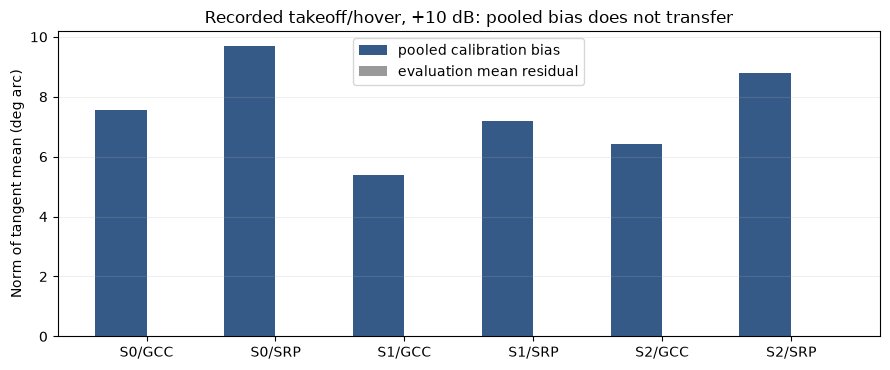

n-audioman-quadcopte -6.0 groups= 6 mean median/P95 deg= 3.55 29.85 mean >30 fraction= 0.054 mean trim shift deg= 0.91
n-audioman-quadcopte 10.0 groups= 6 mean median/P95 deg= 0.29 0.78 mean >30 fraction= 0.0 mean trim shift deg= 0.01
simeonradivoev-mini- -6.0 groups= 6 mean median/P95 deg= 13.11 130.66 mean >30 fraction= 0.449 mean trim shift deg= 5.18
simeonradivoev-mini- 10.0 groups= 6 mean median/P95 deg= 0.33 126.45 mean >30 fraction= 0.401 mean trim shift deg= 5.16


In [6]:
takeoff = [row for row in residuals if row['source_model_comparison']=='recorded_source_approximation' and row['paired_session_id'].startswith('n-audioman') and row['snr_db']=='10.0']
labels = [row['station_id'] + '/' + ('GCC' if row['estimator_variant'].startswith('all_6') else 'SRP') for row in takeoff]
pool_bias = [np.rad2deg(np.hypot(float(row['pooled_calibration_bias_az_arc_rad']),float(row['pooled_calibration_bias_el_arc_rad']))) for row in takeoff]
observed_mean = [float(row['raw_mean_norm_deg']) for row in takeoff]
x = np.arange(len(labels)); fig, ax = plt.subplots(figsize=(9, 3.8))
ax.bar(x-.2, pool_bias, width=.4, color='#365a88', label='pooled calibration bias')
ax.bar(x+.2, observed_mean, width=.4, color='#999999', label='evaluation mean residual')
ax.set_xticks(x, labels); ax.set_ylabel('Norm of tangent mean (deg arc)')
ax.set_title('Recorded takeoff/hover, +10 dB: pooled bias does not transfer')
ax.legend(); ax.grid(axis='y', alpha=.2); plt.tight_layout(); plt.show()
for session in sorted({row['paired_session_id'] for row in residuals if row['source_model_comparison']=='recorded_source_approximation'}):
    for snr in ('-6.0','10.0'):
        group=[row for row in residuals if row['source_model_comparison']=='recorded_source_approximation' and row['paired_session_id']==session and row['snr_db']==snr]
        print(session[:20], snr, 'groups=',len(group), 'mean median/P95 deg=',round(np.mean([float(r['median_geodesic_error_deg']) for r in group]),2),round(np.mean([float(r['p95_geodesic_error_deg']) for r in group]),2),'mean >30 fraction=',round(np.mean([float(r['fraction_error_gt_30deg']) for r in group]),3),'mean trim shift deg=',round(np.mean([float(r['trimmed_95pct_mean_shift_deg']) for r in group]),2))


## Post-hoc sensitivity replay: pooled bias/R vs bias=0/same R

Все 16 уже просмотренных потоков воспроизведены дважды. Контрольная ветвь сверена с опубликованными финальным статусом, числом updates и conditional position RMSE; позиционная истина присоединяется только **после** выполнения causal estimator. Не сравнивайте RMSE при invalid как ноль: такой оценки нет. Нулевой bias — диагностика переноса, **не** кандидат, выбранный по evaluation.


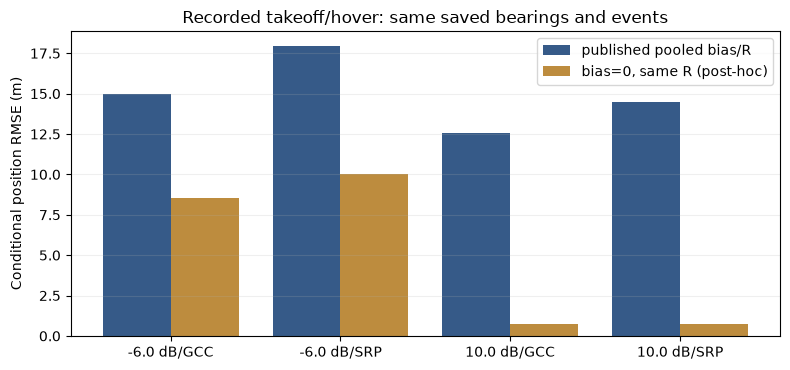

recorded_source_approximation published_pooled_bias_and_R confirmed= 4 / 8 accepted= 36 budget failures= 4
recorded_source_approximation bias_zero_same_R confirmed= 4 / 8 accepted= 36 budget failures= 4
random_broadband published_pooled_bias_and_R confirmed= 6 / 8 accepted= 54 budget failures= 2
random_broadband bias_zero_same_R confirmed= 6 / 8 accepted= 54 budget failures= 2


In [7]:
selected=[row for row in replay if row['source_model_comparison']=='recorded_source_approximation' and row['paired_session_id'].startswith('n-audioman')]
pairs=defaultdict(dict)
for row in selected: pairs[(row['snr_db'],row['estimator_variant'])][row['calibration_variant']]=row
labels=[]; published=[]; zero=[]
for (snr,method),arms in sorted(pairs.items()):
    labels.append(snr+' dB/'+('GCC' if method.startswith('all_6') else 'SRP'))
    published.append(float(arms['published_pooled_bias_and_R']['position_rmse_m_conditional']))
    zero.append(float(arms['bias_zero_same_R']['position_rmse_m_conditional']))
x=np.arange(len(labels)); fig,ax=plt.subplots(figsize=(8,3.8))
ax.bar(x-.2,published,.4,color='#365a88',label='published pooled bias/R')
ax.bar(x+.2,zero,.4,color='#bd8c3e',label='bias=0, same R (post-hoc)')
ax.set_xticks(x,labels);ax.set_ylabel('Conditional position RMSE (m)')
ax.set_title('Recorded takeoff/hover: same saved bearings and events')
ax.legend();ax.grid(axis='y',alpha=.2);plt.tight_layout();plt.show()
for source in ('recorded_source_approximation','random_broadband'):
    for arm in ('published_pooled_bias_and_R','bias_zero_same_R'):
        subset=[r for r in replay if r['source_model_comparison']==source and r['calibration_variant']==arm]
        print(source,arm,'confirmed=',sum(r['final_confirmed']=='True' for r in subset),'/',len(subset),'accepted=',sum(int(r['accepted_update_count']) for r in subset),'budget failures=',sum(r['failure_reason']=='computational_budget_exceeded' for r in subset))


## Почему отказал точный broadband bearing

Для `n-audioman / -6 dB / GCC` ранняя шестисобытийная гипотеза проходит batch gates и становится `tentative`. Подтверждение требует отдельного времени/станций; во время consensus-refit выполняются ещё три batch fits, после чего следующий fit запрещается фиксированным бюджетом 4. Таким образом, статус `computational_budget_exceeded` означает недоведённое подтверждение, а не доказанное несогласие чистых bearings. Таблица ниже сохраняет каждую попытку, IDs, причины и стадии; отобранные гипотезы не называются подтверждёнными.


In [8]:
trace=[r for r in fits if r['source_model_comparison']=='random_broadband' and r['paired_session_id'].startswith('n-audioman') and r['snr_db']=='-6.0' and r['estimator_variant']=='all_6_equal_gcc_wls' and r['calibration_variant']=='published_pooled_bias_and_R' and r['diagnostic_kind']=='batch_fit']
for r in trace: print(f"t={float(r['processing_time_s']):.6f}s | {r['fit_phase']:20s} | count={r['fit_count_after_attempt']} | {r['reason']} | events={len(json.loads(r['construction_event_ids_json']))}")
assert [r['reason'] for r in trace][-1]=='computational_budget_exceeded_before_fit'


t=1.243979s | construction         | count=1 | batch_passed | events=6
t=2.579312s | confirmation_refit   | count=2 | batch_passed | events=7
t=2.594313s | confirmation_refit   | count=3 | batch_passed | events=7
t=2.609312s | confirmation_refit   | count=4 | batch_passed | events=7
t=3.261979s | confirmation_refit   | count=4 | computational_budget_exceeded_before_fit | events=7


## Выводы и ограничения

**Не найдено ошибки реализации** знака, единиц и prediction tangent basis; calibration-only прогон точно воспроизвёл прежние pooled bias/R (`max Δ=0`). **Обнаружена непереносимость** между исходными calibration-записями: Phantom-сеанс содержит широкую, сильно смещённую и тяжёлохвостую ошибку, Mavic-сеанс намного точнее. Объединённый bias/R сильно зависит от первого; это объясняет ухудшение на одном чистом evaluation-сеансе, но причинное влияние характеристик оригинальной записи/среды остаётся неразделённым. Двусторонняя leave-one-session-out диагностика асимметрична из-за большой R проблемного сеанса, а **два сеанса не дают популяционной квалификации**. Post-hoc `bias=0` не утверждён как рабочий вариант. Broadband-отказ при малой angular error объясняется work budget в подтверждающем refit; менять бюджет по evaluation здесь нельзя.
